# 1. Environment Setup

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn tensorflow


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import CategoricalAccuracy,TopKCategoricalAccuracy
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [3]:
# Read in data
path = "Satellite_Data"
classes = ["cloudy","desert","green_area","water"]

dataset =tf.keras.utils.image_dataset_from_directory(
    path,
    labels='inferred',
    label_mode='categorical',
    class_names=classes,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=99
)

Found 5631 files belonging to 4 classes.


In [4]:
# Split the data into Training, Validation, and Test sets
def splits(dataset, train_ratio, val_ratio, test_ratio):
    Data_size = len(dataset)
    train_size = int(train_ratio * Data_size)
    val_size = int(val_ratio * Data_size)
    test_size = int(test_ratio * Data_size)

    train_dataset = dataset.take(train_size)
    val_test_dataset = dataset.skip(train_size)
    val_dataset = val_test_dataset.take(val_size)
    test_dataset = val_test_dataset.skip(val_size).take(test_size)

    return train_dataset, val_dataset, test_dataset

train_ratio =0.70
val_ratio = 0.15
test_ratio =0.15

train,val,test = splits(dataset,train_ratio,val_ratio,test_ratio)

# 2. Data Visualization
Let's visualize the data so we can ensure our data was imported correctly, as well as understand what we are working with

2024-10-31 22:14:54.251809: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


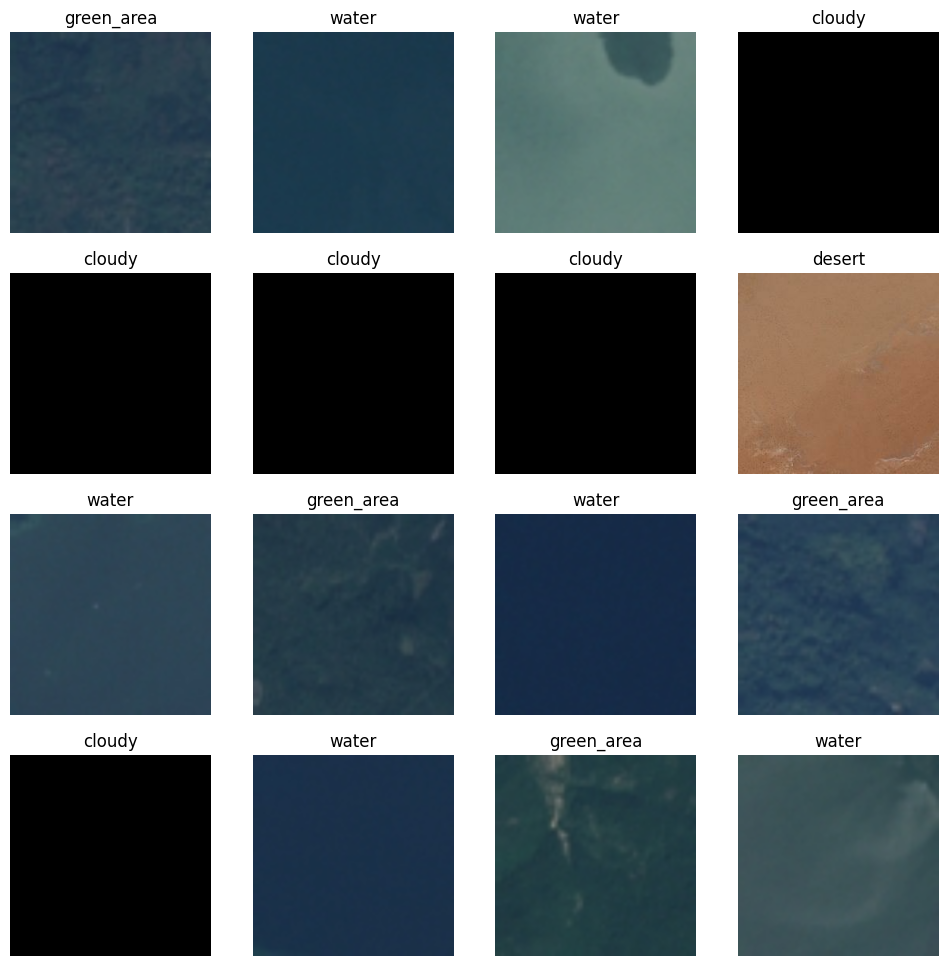

In [5]:
plt.figure(figsize = (12,12))

for images, labels in dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4,4, i+1)
    plt.imshow(images[i]/255.)
    plt.title(classes[tf.argmax(labels[i],axis=0).numpy()])
    plt.axis("off")


2024-10-31 22:14:57.288857: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


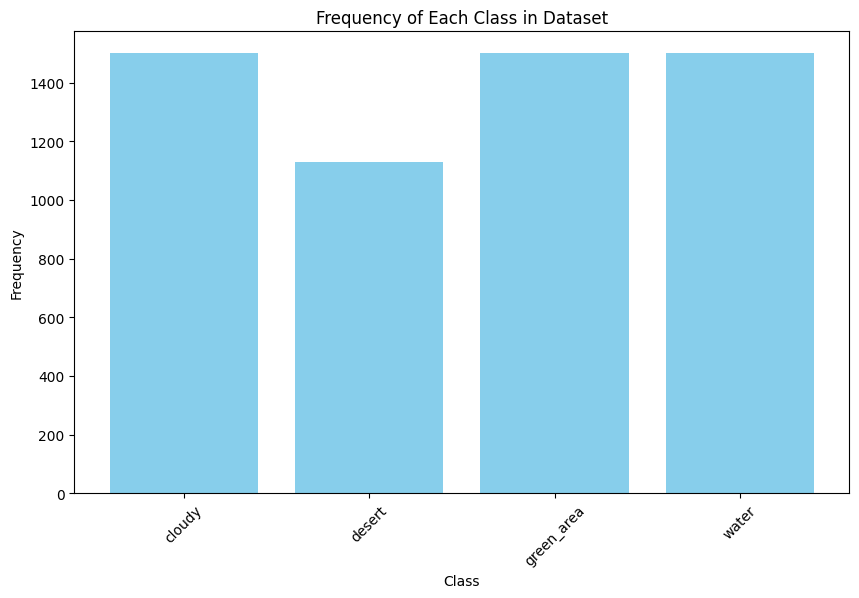

In [6]:
# Initialize class count
class_count = {class_name: 0 for class_name in classes}

# Count occurrences of each class
for images, labels in dataset:
    for label in labels:
        class_name = classes[tf.argmax(label).numpy()]
        class_count[class_name] += 1

# Create a DataFrame for visualization
df = pd.DataFrame(list(class_count.items()), columns=['Class', 'Count'])

# Plot the frequency of each class
plt.figure(figsize=(10, 6))
plt.bar(df['Class'], df['Count'], color='skyblue')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Frequency of Each Class in Dataset')
plt.xticks(rotation=45)
plt.show()

# 3. Build a Base Model
Let's construct a simple model to get a baseline understanding of how our data is performing

## 3.1 Model Structre
**Input Layer**
- Shape: (256, 256, 3) (for 256x256 pixel RGB images).

**Normalization Layer**
- Rescaling: Scales pixel values from [0, 255] to [0, 1] to improve model stability and training speed.

**Convolution and Pooling Layers**
- Conv2D (16 filters, 3x3 kernel, ReLU activation): Learns 16 feature maps with a 3x3 filter size, using ReLU activation to introduce non-linearity.

**MaxPooling2D:** 
- Reduces spatial dimensions, retaining key features while decreasing computational load.

**Flatten Layer**
- Converts the 2D feature maps into a 1D vector to connect with dense layers.

**Fully Connected (Dense) Layers**
- Dense (128 units, ReLU activation): Dense layer with 128 neurons for learning complex representations from the extracted features.
- Dense (4 units, Softmax activation): Output layer with 4 neurons (one per class) and softmax activation for multi-class classification.

**Compilation**
- Optimizer: Adam – an adaptive learning rate optimization algorithm.
- Loss: Categorical cross-entropy – suitable for multi-class classification.
- Metric: Accuracy – to evaluate classification performance.


In [7]:
# Build the model
model = Sequential([
    layers.Input(shape=(256, 256, 3)),         # Input layer for 256x256 RGB images
    layers.Rescaling(1./255),                  # Normalize pixel values

    layers.Conv2D(16, 3, padding='same', activation='relu'),  # Conv layer with 16 filters
    layers.MaxPooling2D(),                     # Down-sample with max pooling

    layers.Conv2D(32, 3, padding='same', activation='relu'),  # Conv layer with 32 filters
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),  # Conv layer with 64 filters
    layers.MaxPooling2D(),

    layers.Flatten(),                          # Flatten for dense layers
    layers.Dense(128, activation='relu'),      # Dense layer with 128 units
    layers.Dense(4, activation='softmax')      # Output layer for 4-class classification
])

# Compile the model with Adam optimizer, categorical cross-entropy loss, and accuracy metric
model.compile(optimizer='adam',
              loss=CategoricalCrossentropy(),
              metrics=['accuracy'])


In [8]:
# Model Architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,412,836 (32.09 MB)

 Trainable params: 8,412,836 (32.09 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the Model
history = model.fit(
    train,
    validation_data=val,
    epochs=5
)

# Test Model
test_loss, test_accuracy = model.evaluate(test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 50s 395ms/step - accuracy: 0.7307 - loss: 0.5928 - val_accuracy: 0.8774 - val_loss: 0.2819
Epoch 2/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 47s 384ms/step - accuracy: 0.8890 - loss: 0.2396 - val_accuracy: 0.9207 - val_loss: 0.2144
Epoch 3/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 48s 390ms/step - accuracy: 0.8972 - loss: 0.2309 - val_accuracy: 0.8329 - val_loss: 0.3285
Epoch 4/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 0.8855 - loss: 0.2382 - val_accuracy: 0.8870 - val_loss: 0.2143
Epoch 5/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 364ms/step - accuracy: 0.9151 - loss: 0.1867 - val_accuracy: 0.8413 - val_loss: 0.2921
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.8620 - loss: 0.2803
Test Accuracy: 84.74%


## 3.2 Performances

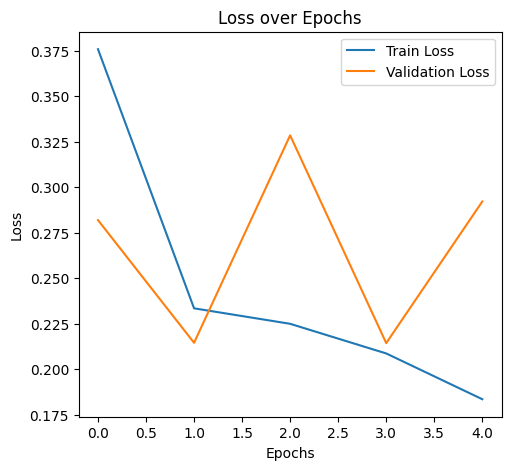

In [10]:
# Plot the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# 4. Improvements

## 4.1 Increase Epochs
Our models' loss is extremely rigid and does not converge, let's increase the number of epochs. For brevity sake, let's also implement early stopping

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.9179 - loss: 0.1774 - val_accuracy: 0.9279 - val_loss: 0.1597
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 888s 7s/step - accuracy: 0.9286 - loss: 0.1519 - val_accuracy: 0.9219 - val_loss: 0.1873
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 50s 407ms/step - accuracy: 0.9227 - loss: 0.1746 - val_accuracy: 0.9411 - val_loss: 0.1436
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 374ms/step - accuracy: 0.9186 - loss: 0.1862 - val_accuracy: 0.9171 - val_loss: 0.1987
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 49s 400ms/step - accuracy: 0.9363 - loss: 0.1486 - val_accuracy: 0.9207 - val_loss: 0.1613
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 49s 395ms/step - accuracy: 0.9243 - loss: 0.1715 - val_accuracy: 0.9207 - val_loss: 0.1771
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 369ms/step - accuracy: 0.9287 - loss: 0.1664 - val_accuracy: 0.9099 - val_loss: 0.1894
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 363ms/step - accuracy: 0.9254 - loss: 0.1

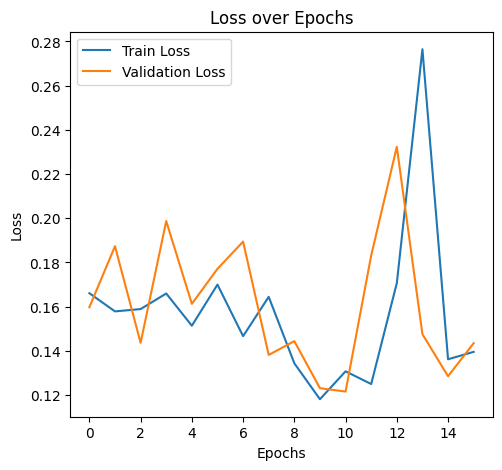

In [11]:
# Early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Increase epochs and use early stopping
history = model.fit(
    train,
    validation_data=val,
    epochs=50,  # Increased number of epochs
    callbacks=[early_stopping]  # Early stopping callback
)

# Test Model
test_loss, test_accuracy = model.evaluate(test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()


## 4.2 Implement Dropout and Batch Normalization
Our model is overfitting - denoted by the large gap between training and validation loss - let's try implementing dropout layers and batch normalization.

Epoch 1/3
123/123 ━━━━━━━━━━━━━━━━━━━━ 76s 605ms/step - accuracy: 0.8325 - loss: 0.4342 - val_accuracy: 0.2356 - val_loss: 10.1041
Epoch 2/3
123/123 ━━━━━━━━━━━━━━━━━━━━ 76s 621ms/step - accuracy: 0.8913 - loss: 0.2651 - val_accuracy: 0.2380 - val_loss: 14.0664
Epoch 3/3
123/123 ━━━━━━━━━━━━━━━━━━━━ 77s 626ms/step - accuracy: 0.9037 - loss: 0.2314 - val_accuracy: 0.2380 - val_loss: 14.7000
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.2286 - loss: 10.4125
Test Accuracy: 25.72%


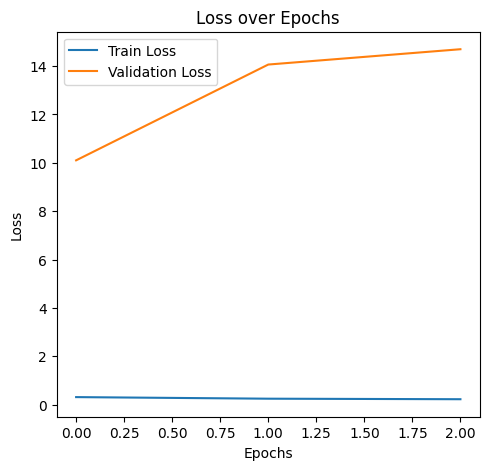

In [12]:
# Build the updated model
model = Sequential([
    layers.Input(shape=(256, 256, 3)),                     # Input layer for 256x256 RGB images
    layers.Rescaling(1./255),                              # Normalize pixel values

    layers.Conv2D(16, 3, padding='same', activation='relu'),  # Conv layer with 16 filters
    layers.BatchNormalization(),                           # Batch normalization for stability
    layers.MaxPooling2D(),                                 # Down-sample with max pooling
    layers.Dropout(0.25),                                  # Dropout for regularization

    layers.Conv2D(32, 3, padding='same', activation='relu'),  # Conv layer with 32 filters
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(64, 3, padding='same', activation='relu'),  # Conv layer with 64 filters
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.Flatten(),                                      # Flatten for dense layers
    layers.Dense(128, activation='relu'),                  # Dense layer with 128 units
    layers.BatchNormalization(),
    layers.Dropout(0.5),                                   # Dropout before final layer

    layers.Dense(4, activation='softmax')                  # Output layer for 4-class classification
])

# Compile the model with Adam optimizer, categorical cross-entropy loss, and accuracy metric
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss=CategoricalCrossentropy(),
              metrics=['accuracy'])

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    train,
    validation_data=val,
    epochs=3,  # Increased number of epochs
    callbacks=[early_stopping]  # Early stopping callback
)

# Test Model
test_loss, test_accuracy = model.evaluate(test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()


## 4.3 Transfer Learning
**Transfer learning**
A machine learning technique where a model developed for one task is reused as the starting point for a model on a related task. Transfer learning can significantly reduce training time and improve performance.

### Common Architectures for Transfer Learning
**AlexNet:**
- One of the earliest CNN architectures
- It has five convolutional layers followed by three fully connected layers, using ReLU activation and dropout to reduce overfitting.
- AlexNet is a simpler architecture compared to newer models but is often used as a baseline.

**VGG16 and VGG19:**
- These are deeper models with 16 and 19 layers, respectively, using small 3x3 convolution filters.
- They are known for simplicity and strong performance on a variety of image classification tasks.

**ResNet (Residual Networks):**
- Introduces residual connections (or skip connections) to allow much deeper networks (up to 152 layers). These connections help avoid the vanishing gradient problem, making it effective for complex tasks.

123/123 ━━━━━━━━━━━━━━━━━━━━ 680s 6s/step - accuracy: 0.9130 - loss: 0.3410 - val_accuracy: 0.9988 - val_loss: 0.0163
26/26 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - accuracy: 0.9967 - loss: 0.0330
Test Accuracy: 99.64%


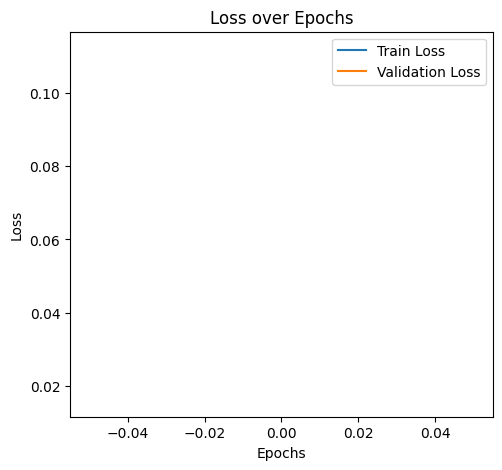

In [13]:
# Load the VGG16 model with pre-trained weights and exclude the top layer
base_model = VGG16(input_shape=(256, 256, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model's layers

# Build the new model on top of VGG16
model = models.Sequential([
    base_model,
    layers.Flatten(),                      # Flatten the output of VGG16
    layers.Dense(128, activation='relu'),  # Dense layer to learn task-specific patterns
    layers.Dropout(0.5),                   # Dropout for regularization
    layers.Dense(4, activation='softmax')  # Output layer for 4-class classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss=CategoricalCrossentropy(),
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train,
    validation_data=val,
    epochs=1,  # Increased number of epochs
)

# Test Model
test_loss, test_accuracy = model.evaluate(test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()